In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import geopandas as gpd
import numpy as np
from collections import Counter
import re
import pandas as pd
from matplotlib.patches import Ellipse

In [2]:
from chalk import chalk, ChalkEffect, _CHALK_CYCLE

In [3]:
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15

# green colors: #29635f, #1e5647

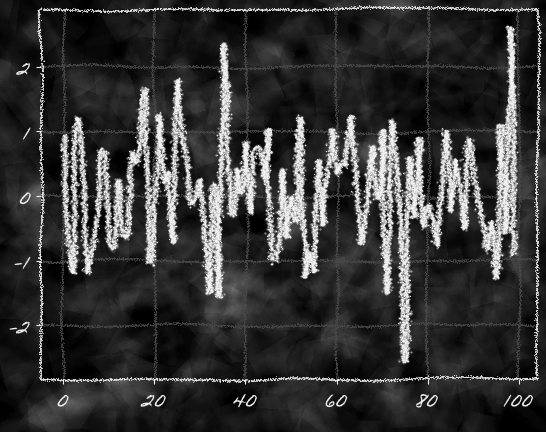

In [ ]:
# who cleans the blackboard like this?..
with chalk(sketch=None, board='k', panel='k', board_smudges=800, 
smudge_alpha=0.07, passes=3, wander=1., spacing=1, spread=1.5, jitter=0.3,
font='/Users/mouse13/Library/Fonts/HomemadeApple-9zz5.ttf'):
    plt.figure()
    plt.plot(np.random.randn(100))
    plt.savefig('board_smudges_test_black.png', dpi=120, bbox_inches='tight')
    plt.show()


/var/folders/d6/lx3ld9gd6kg4j1qq4qkztcq80000gn/T/ipykernel_70360/1361618069.py:12: RuntimeWarning: divide by zero encountered in divide
  plt.plot(x, 1/x, ls='--', lw=5, label='1/x')
/var/folders/d6/lx3ld9gd6kg4j1qq4qkztcq80000gn/T/ipykernel_70360/1361618069.py:13: RuntimeWarning: divide by zero encountered in log10
  plt.plot(x, np.log10(x), ls='--', lw=9, label='lg(x)')


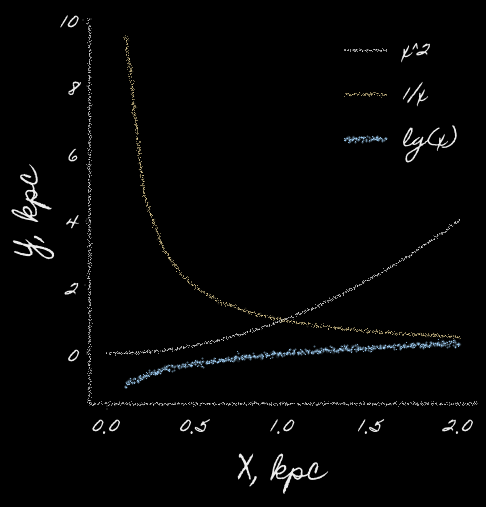

In [12]:
'''Works best with lines; doesn't produce much variability in the linewidth'''

with chalk(sketch=None, board='black', panel='black', 
font='/Users/mouse13/Library/Fonts/HomemadeApple-9zz5.ttf', 
grain=ChalkEffect(spacing=2, spread=1.5, jitter=0.5, 
wander=0.0, grain=2.2, alpha=0.9, passes=3, seed=None, keep_fill=False, 
min_extent=0.0, flat_bg=1., ref_linewidth=10.)):

    x = np.linspace(0, 2, 20)
    fig = plt.figure(figsize=(5, 5))
    plt.plot(x, x**2, ls='--', lw=0.1, label='x^2')
    plt.plot(x, 1/x, ls='--', lw=5, label='1/x')
    plt.plot(x, np.log10(x), ls='--', lw=9, label='lg(x)')
    # linewidth is not very sensitive to the ref_linewidth
    plt.grid(False)
    
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.legend(loc='upper right', fontsize=15, frameon=False)
    # frameon=True is not dense enough

    plt.xlabel('X, kpc', fontsize=20)
    plt.ylabel('Y, kpc', fontsize=20)

    plt.gca().patch.set_path_effects([])
    plt.savefig('line_test.png', dpi=120, bbox_inches='tight')
    plt.show()
    plt.close()

In [ ]:
# test with orbits and fill of the patch; it's recommended to play with fill_density to get better results

orbits = np.load('orbit_test.npz.npy')
orbits.shape

(2, 869)

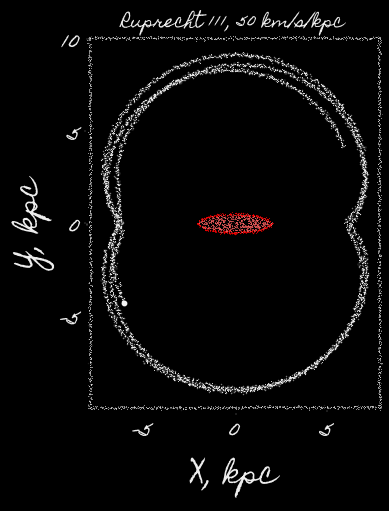

In [99]:
with chalk(sketch=None, board='black', panel='black', 
font='/Users/mouse13/Library/Fonts/HomemadeApple-9zz5.ttf', 
grain=ChalkEffect(spacing=2, spread=1.5, jitter=0.5, 
wander=0.2, grain=2.2, alpha=0.9, passes=3, seed=None, keep_fill=False, 
min_extent=0.0, flat_bg=1., ref_linewidth=3., fill_density=6000)):
    plt.figure()
    plt.plot(orbits[0], orbits[1], lw=2., color=_CHALK_CYCLE[0])
    plt.scatter(orbits[0][-1], orbits[1][-1], s=10)
    plt.grid(False)
    circle = Ellipse((0, 0), 4, 1, fill=True, edgecolor='red', lw=1, alpha=0.9)
    plt.gca().add_patch(circle)

    plt.gca().set_aspect('equal')

    plt.xlabel('X, kpc', fontsize=20)
    plt.ylabel('Y, kpc', fontsize=20)

    plt.title('Ruprecht 111, 50 km/s/kpc')
    plt.savefig('orbit_test.png', dpi=300, bbox_inches='tight')
    plt.show()

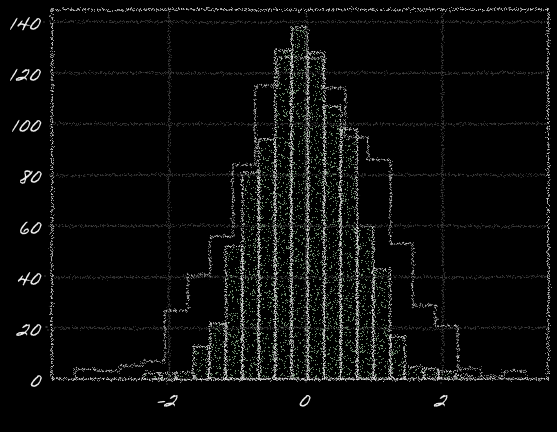

In [101]:
with chalk(sketch=None, board='black', panel='black', 
font='fonts/HomemadeApple-9zz5.ttf', 
grain=ChalkEffect(spacing=2, spread=1.5, jitter=0.5, 
wander=0.2, grain=2.2, alpha=0.9, passes=3, seed=None, keep_fill=False, 
min_extent=0.0, flat_bg=1., ref_linewidth=3., fill_density=1000)):
    rand = np.random.normal(0, 1, 1000)
    rand2 = np.random.normal(0., 0.7, 1000)
    plt.hist(rand, bins=20, alpha=0.5, histtype='step')
    plt.hist(rand2, bins=20, color='green')
    plt.savefig('hist_test.png', dpi=120, transparent=False, bbox_inches='tight')
    plt.show()

In [46]:
df_street = gpd.read_file('streets_test.geojson', driver='GeoJSON')

/Users/mouse13/anaconda3/envs/ocenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GeoJSON does not support open option DRIVER
  return ogr_read(


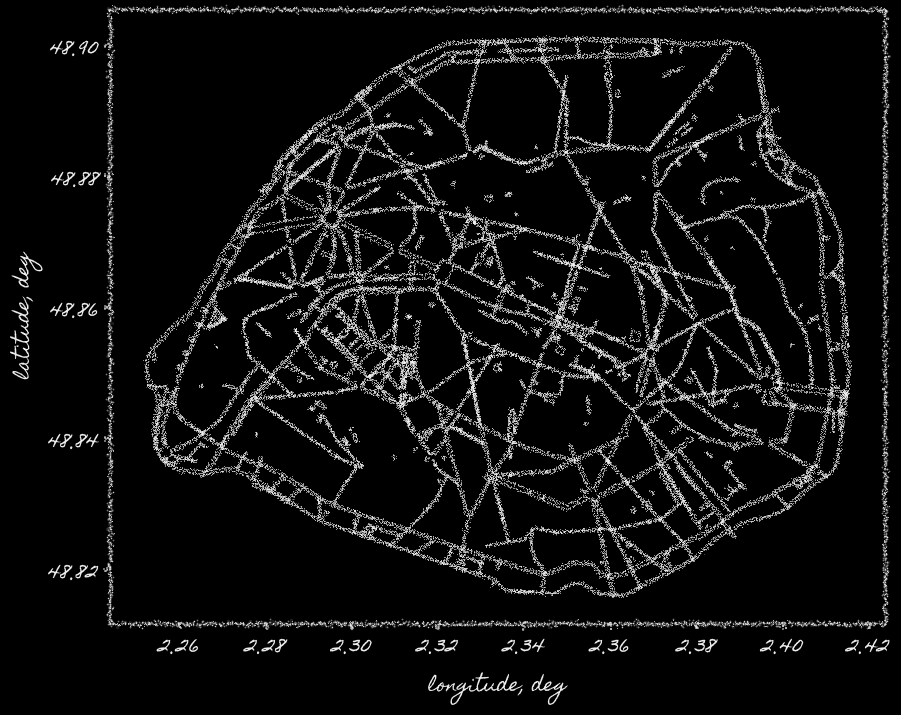

In [93]:
with chalk(sketch=None, board='black', panel='black', 
font='fonts/HomemadeApple-9zz5.ttf', 
grain=ChalkEffect(flat_bg=0.5, keep_fill=False, ref_linewidth=1., min_extent=0.1, wander=0.)):
    fig, ax = plt.subplots(figsize=(10, 10))
    df_street.loc[(df_street.largeur > 20)].boundary.plot(lw=0.1, ax=ax)
    for coll in ax.collections:
        coll.set_path_effects(mpl.rcParams["path.effects"])
    ax.grid(False)
    plt.xlabel('longitude, deg', fontsize=13)
    plt.ylabel('latitude, deg', fontsize=13)
    plt.savefig('street_test.png', dpi=120, bbox_inches='tight')
    plt.show()

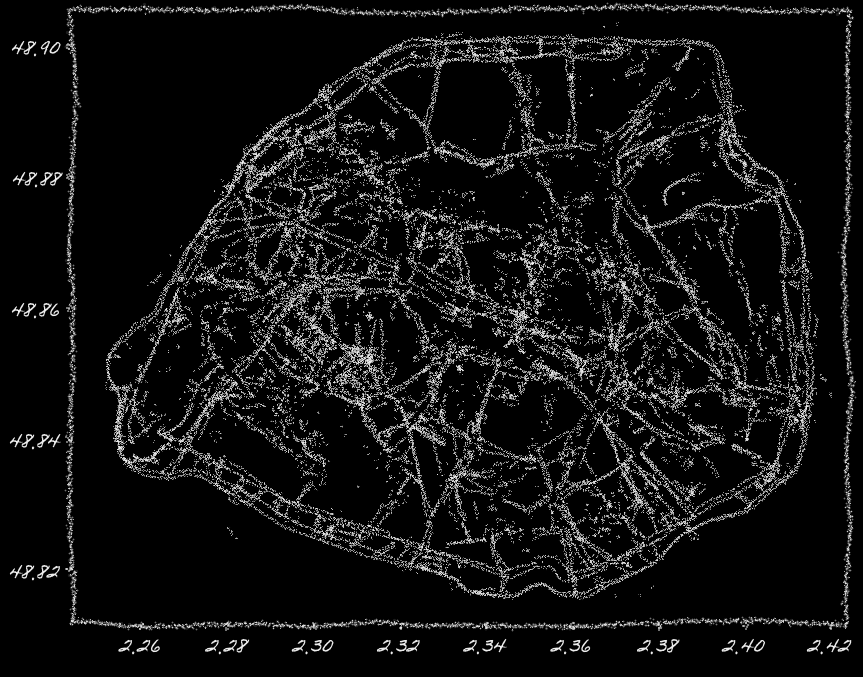

In [95]:
# map of Paris when you're leaving the bar at 4 am in the morning -- change wander to get wigglier lines

with chalk(sketch=None, board='black', panel='black', 
font='fonts/HomemadeApple-9zz5.ttf', 
grain=ChalkEffect(flat_bg=0.5, keep_fill=False, ref_linewidth=1., min_extent=0.1, wander=1.8)):
    fig, ax = plt.subplots(figsize=(10, 10))
    df_street.loc[(df_street.largeur > 20)].boundary.plot(lw=0.1, ax=ax)
    for coll in ax.collections:
        coll.set_path_effects(mpl.rcParams["path.effects"])
    ax.grid(False)
    plt.savefig('street_drunk_test.png', dpi=120, bbox_inches='tight')
    plt.show()

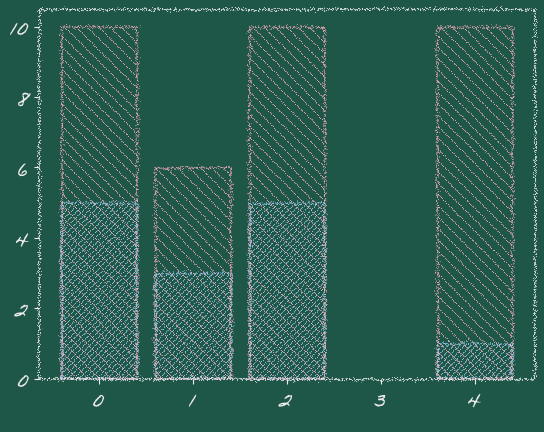

In [96]:
# test hatch fill

x = [0, 1, 2, 4]
y = [5, 3, 5, 1]
y2 = [10, 6, 10, 10]
with chalk(sketch=None, font='fonts/HomemadeApple-9zz5.ttf', board='#1e5647', panel='#1e5647'):
    fig, ax = plt.subplots()
    ax.bar(x, y, facecolor="none", edgecolor="#a8d8ff", hatch="//")
    ax.bar(x, y2, facecolor="none", edgecolor="#ffb3c6", hatch="\\")
    # ax.grid(color='lightgray', alpha=0.5)
    ax.grid(False)
    plt.savefig('bar_test.png', dpi=120, bbox_inches='tight')
    plt.show()
